In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

In [3]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

optimization = optuna.create_study(direction="minimize") #Finding the parameters that minimize the MAE
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-01-30 15:05:32,221] A new study created in memory with name: no-name-7d37f772-6df0-4ca0-929a-50ca4c3e9b35
[I 2026-01-30 15:05:33,068] Trial 0 finished with value: 23010.910834516257 and parameters: {'learning_rate': 0.0318390448142279, 'max_depth': 5, 'subsample': 0.7535751571527708, 'colsample_bytree': 0.8576686450643682}. Best is trial 0 with value: 23010.910834516257.
[I 2026-01-30 15:05:33,312] Trial 1 finished with value: 23366.656434765435 and parameters: {'learning_rate': 0.011207258235666883, 'max_depth': 2, 'subsample': 0.6405101339586193, 'colsample_bytree': 0.8037049415950708}. Best is trial 0 with value: 23010.910834516257.
[I 2026-01-30 15:05:33,645] Trial 2 finished with value: 23488.079465695908 and parameters: {'learning_rate': 0.08327341738576016, 'max_depth': 4, 'subsample': 0.6389065984137842, 'colsample_bytree': 0.6797124899999026}. Best is trial 0 with value: 23010.910834516257.
[I 2026-01-30 15:05:34,099] Trial 3 finished with value: 22943.610101013204 and

Optimal Parameters: {'learning_rate': 0.010013627107064577, 'max_depth': 5, 'subsample': 0.7043073828519925, 'colsample_bytree': 0.7889310757942598}
XGBoost Error: 26305.74727672296
Mean XGBoost Error: 20780.331231239386


Sample0: True = 53550.00s, Predicted = 55317.48s, Error=1767.48s
Sample1: True = 83610.00s, Predicted = 50768.77s, Error=32841.23s
Sample2: True = 93015.00s, Predicted = 55609.87s, Error=37405.13s
Sample3: True = 73710.00s, Predicted = 58511.80s, Error=15198.20s
Sample4: True = 55650.00s, Predicted = 51313.40s, Error=4336.60s
Sample5: True = 38625.00s, Predicted = 60585.28s, Error=21960.28s
Sample6: True = 73170.00s, Predicted = 70580.45s, Error=2589.55s
Sample7: True = 55140.00s, Predicted = 48122.21s, Error=7017.79s
Sample8: True = 40740.00s, Predicted = 48176.61s, Error=7436.61s
Sample9: True = 75480.00s, Predicted = 54482.29s, Error=20997.71s
Sample10: True = 83955.00s, Predicted = 55428.64s, Error=28526.36s
Sample11: True = 87045.00s, Predicted = 59914.95s, Error=27130.05s
Sample12: True = 86970.00s, Predicted = 52437.03s, Error=34532.97s
Sample13: True = 90210.00s, Predicted = 62547.29s, Error=27662.71s
Sample14: True = 30180.00s, Predicted = 66680.02s, Error=36500.02s
Sample15: 

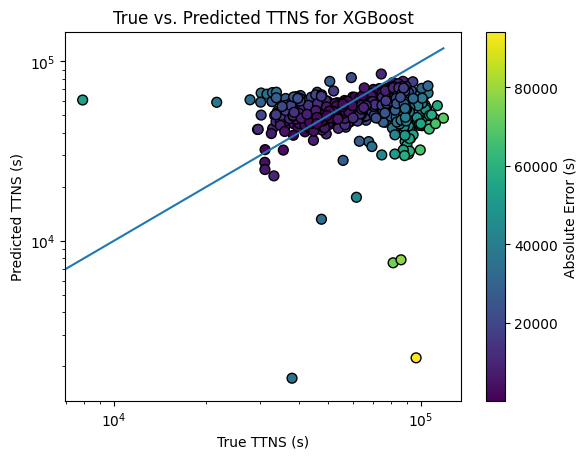

In [4]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction

absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()

 93%|=================== | 722/773 [00:12<00:00]       

XG Boost Drivers: time_since     4407.912790
form_fac       3163.484354
slip_size      2832.960908
tide_height    2105.402050
tide_deriv     1849.665805
high_t_evt      220.901274
dtype: float64


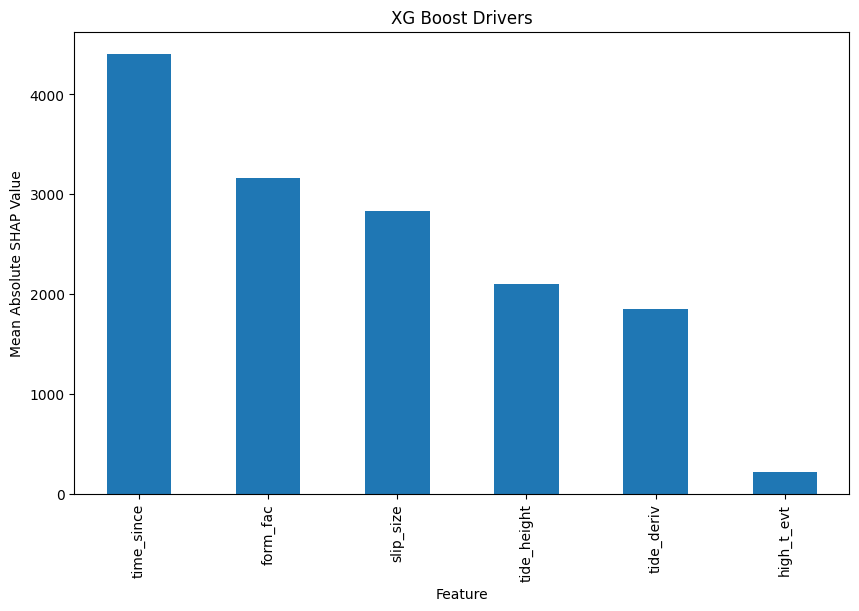

In [5]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
